In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading, plot_PvT_across_var, \
                                                        plot_hist_across_var
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import re
big_plt_font()

In [10]:
home_dir = '/home/electron/'
data_dir = home_dir + f'data/experiment_{datetime.datetime.now().strftime("%m%d%Y")}'

In [16]:
file = load_latest_data() 
file['filename']

'/home/electron/data/experiment_07162026/RFPowerSweepDifferentialNAcquisition_10-46-56.h5'

In [17]:
background = '/home/electron/data/experiment_07162026/RFPowerSweepDifferentialNAcquisition_10-46-56.h5'

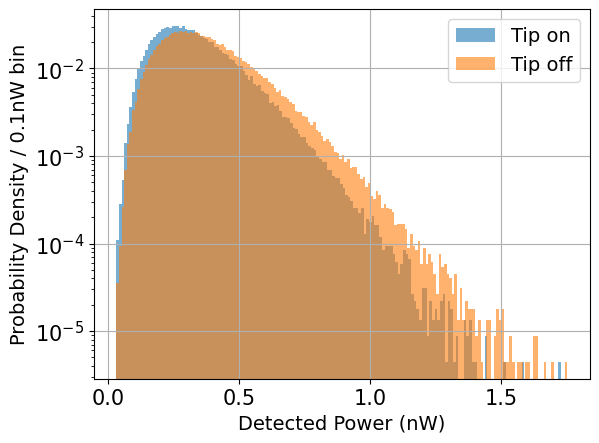

In [55]:
plot_hist(file=None, 
          background_file=background, 
          data_dir=home_dir)

In [53]:
plot_individual_PvT('data/experiment_07162026/RFPowerSweepDifferentialNAcquisition_14-30-24.h5', data_dir=home_dir)

In [71]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisition', start_time='00:10:00', stop_time='08:00:00')
plot_PvT_across_var(tip_on_files, '', var='P_detect') 

Scanning datasets for P_detect and calculating global y-limits...
Scan complete. Found 6 valid P_detect configurations.


In [69]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisition', start_time='00:10:00', stop_time='08:00:00')
tip_off_files = [
    background
]
plot_hist_across_var(tip_on_files, tip_off_files, '', var='P_detect') 

Scanning datasets for P_detect and calculating global x-limits...
Scan complete. Found 6 valid P_detect configurations.


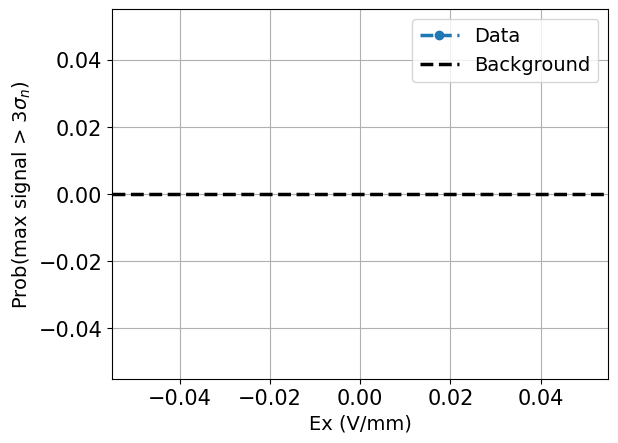

In [19]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepOnOffDifferential', start_time='11:00:00', stop_time='12:00:00')

tip_off_files = [
    background
]
plot_Prob_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='Ex', xlabel='Ex (V/mm)', sigma_cutoff=3)

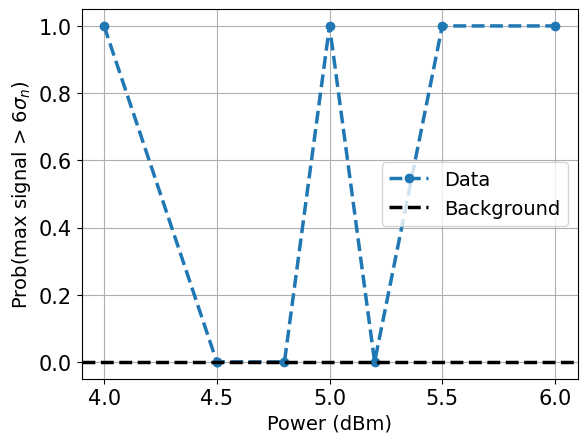

In [39]:
tip_on_files = list_files_in_time_range(data_dir, 
                                        name='RFPowerSweepDifferentialNAcquisition', start_time='12:30:00', stop_time='14:00:00')

tip_off_files = [
    background
]
plot_Prob_vs_var(tip_on_files, tip_off_files, data_dir=home_dir, var='P_detect', xlabel=r'Power (dBm)', sigma_cutoff=6)

In [9]:
data_files = list_files_in_time_range(data_dir, name='RFPowerConstSweepDifferential', stop_time='10:00:00')
compare_PvT_U2_Ex_continuous_loading(data_files, fix_ylim=True)

Scanning datasets and calculating global y-limits...
Scan complete. Found 10 valid Ex/U2 configurations.


In [10]:
data_files = list_files_in_time_range(data_dir, name='RFPowerConstSweepDifferential', stop_time='10:00:00')
compare_hist_U2_Ex_continuous_loading(data_files)

Scanning datasets and calculating global x-limits...
Scan complete. Found 10 valid Ex/U2 configurations.


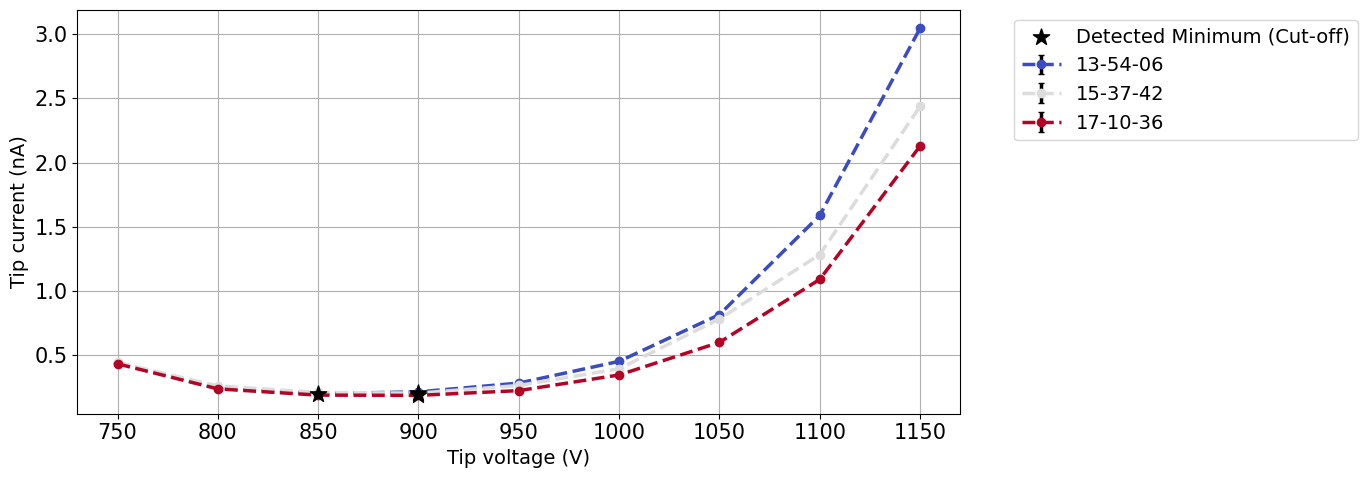

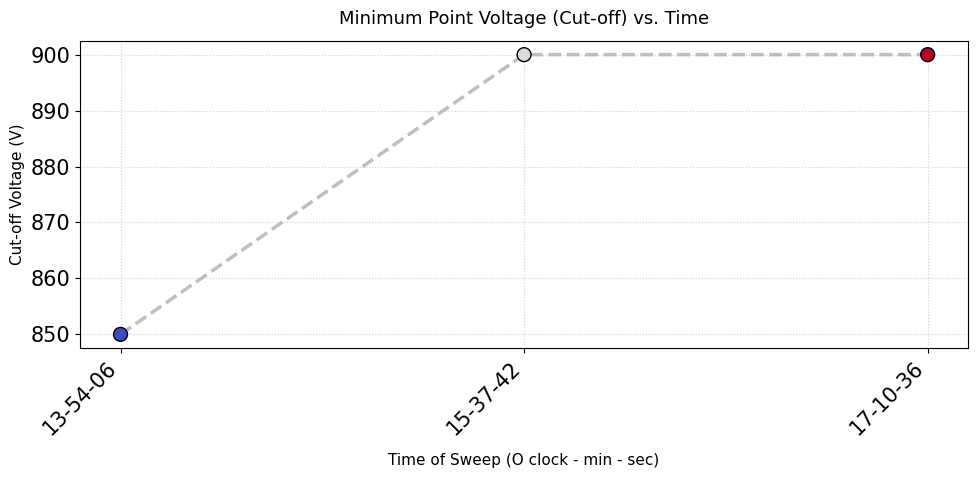

In [ ]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the list of files and sort them in ascending chronological order
all_files = list_files_in_time_range(data_dir, name='TipVoltageSweepDifferential', start_time='09:58:00')
all_files = sorted(all_files)  
num_files = len(all_files)

# Generate a distinct color palette using 'coolwarm'
colors = plt.cm.coolwarm(np.linspace(0, 1, num_files))

# Initialize lists to track data for the single summary graph
sweep_indices = []
sweep_labels = []
cutoff_voltage_list = []

# ==========================================
# FIGURE 1: Raw Voltage Sweeps (Stretched)
# ==========================================
plt.figure(figsize=(14, 5)) 

for i, file_path in enumerate(all_files):
    file = load_h5_data(file_path)
    
    v_data = file['all_V']
    mean_i_nA = np.mean(file['all_I'], axis=1) * 1e9
    std_i_nA = np.std(file['all_I'], axis=1) * 1e9
    
    # --- EXTRACT TIMESTAMP FOR LEGEND ---
    filename = os.path.basename(file_path)
    time_match = re.search(r'\d{2}-\d{2}-\d{2}', filename)
    
    if time_match:
        sweep_label = time_match.group(0) # e.g. "09-58-14"
    else:
        sweep_label = filename.replace('.h5', '')
    
    # Plot the full raw sweep line with black error bars
    plot_errbar(
        v_data, 
        mean_i_nA, 
        yerr=std_i_nA, 
        fmt='.--', 
        xlabel='Tip voltage (V)', 
        ylabel='Tip current (nA)', 
        color=colors[i],       
        ecolor='black',        
        label=sweep_label      
    )
    
    # --- CUT-OFF AS THE MINIMUM POINT OF THE DATA ---
    min_idx = np.argmin(mean_i_nA)
    cutoff_v = v_data[min_idx]
    cutoff_i = mean_i_nA[min_idx]
                
    # Store the detected values for the summary plot
    sweep_indices.append(i + 1)
    sweep_labels.append(sweep_label)
    cutoff_voltage_list.append(cutoff_v)
    
    # Mark the minimum point directly on the raw graph with a black star
    plt.scatter(cutoff_v, cutoff_i, color='black', marker='*', s=150, zorder=5, 
                label='Detected Minimum (Cut-off)' if i == 0 else "")

# Format Figure 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


# ==========================================
# FIGURE 2: Single Summary Plot (Cut-off vs Time)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 5))  # Adjusted size for a single, focused graph

# Plot trend line to guide the eye
ax2.plot(sweep_indices, cutoff_voltage_list, color='gray', linestyle='--', alpha=0.5, zorder=1)

# Scatter plot using 'coolwarm' colormap to keep visual continuity with Figure 1
ax2.scatter(
    sweep_indices, 
    cutoff_voltage_list, 
    c=sweep_indices, 
    cmap='coolwarm', 
    edgecolor='black', 
    s=100, 
    zorder=2
)

# Format the summary graph
ax2.set_title('Minimum Point Voltage (Cut-off) vs. Time', fontsize=13, pad=12)
ax2.set_xlabel('Time of Sweep (O clock - min - sec)', fontsize=11, labelpad=10)
ax2.set_ylabel('Cut-off Voltage (V)', fontsize=11)

# Map the exact timestamps to the x-axis ticks
ax2.set_xticks(sweep_indices)
ax2.set_xticklabels(sweep_labels, rotation=45, ha='right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [31]:
import os
import glob
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Placeholder for your custom loading function ---
# Ensure this function is imported or defined in your script
# from your_module import load_h5_data

def plot_voltage_at_target_current(folders, file_prefix, target_current=2.0):
    # folders = [folder1, folder2]
    timestamps = []
    voltages = []
    
    for folder in folders:
        # Find all files starting with the specific prefix
        search_pattern = os.path.join(folder, f"{file_prefix}*")
        file_paths = glob.glob(search_pattern)
        
        for file_path in file_paths:
            # Skip directories if any match the pattern
            if not os.path.isfile(file_path):
                continue
                
            try:
                # 1. Get the file's save timestamp (modification time)
                mtime = os.path.getmtime(file_path)
                file_time = datetime.fromtimestamp(mtime)
                
                # 2. Load and process the H5 data
                file_data = load_h5_data(file_path)
                # print(file_data)
                v_data = -np.array(file_data['all_V']) - file_data['V_fixed']
                mean_i_nA = np.mean(file_data['all_I'], axis=1) * 1e9
                
                # 3. Discard data if the max current doesn't reach the target (2 nA)
                if np.max(mean_i_nA) < target_current or np.min(mean_i_nA) > target_current:
                    # print(f"Skipping {os.path.basename(file_path)}: Max current ({np.max(mean_i_nA):.2f} nA) < {target_current} nA")
                    continue
                
                # 4. Find the voltage where mean_i_nA == target_current
                # Sort arrays by current to ensure np.interp works correctly if the data isn't perfectly monotonic
                sort_idx = np.argsort(mean_i_nA)
                mean_i_sorted = mean_i_nA[sort_idx]
                v_sorted = v_data[sort_idx]
                
                # Linear interpolation to find the precise voltage
                v_at_target = np.interp(target_current, mean_i_sorted, v_sorted)
                
                timestamps.append(file_time)
                voltages.append(v_at_target)
                
            except Exception as e:
                print(f"Error processing {os.path.basename(file_path)}: {e}")

    if not timestamps:
        print("No files met the criteria.")
        return

    # 5. Sort the collected data chronologically for a clean time-series plot
    sorted_pairs = sorted(zip(timestamps, voltages))
    timestamps_sorted, voltages_sorted = zip(*sorted_pairs)

    # 6. Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(timestamps_sorted, voltages_sorted, marker='.', linestyle='--', label=f'V at {target_current} nA')
    
    # Format the X-axis to display dates/times clearly
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gcf().autofmt_xdate()  # Rotates the dates so they don't overlap
    
    plt.xlabel('Time (File Saved)')
    plt.ylabel(r'Voltage (V)')
    plt.title(f'Voltage Required to Reach {target_current} nA Over Time')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# folder_a = "./data_folder_1"
# folder_b = "./data_folder_2"
# prefix = "experiment_run_"
# plot_voltage_at_target_current(folder_a, folder_b, prefix)

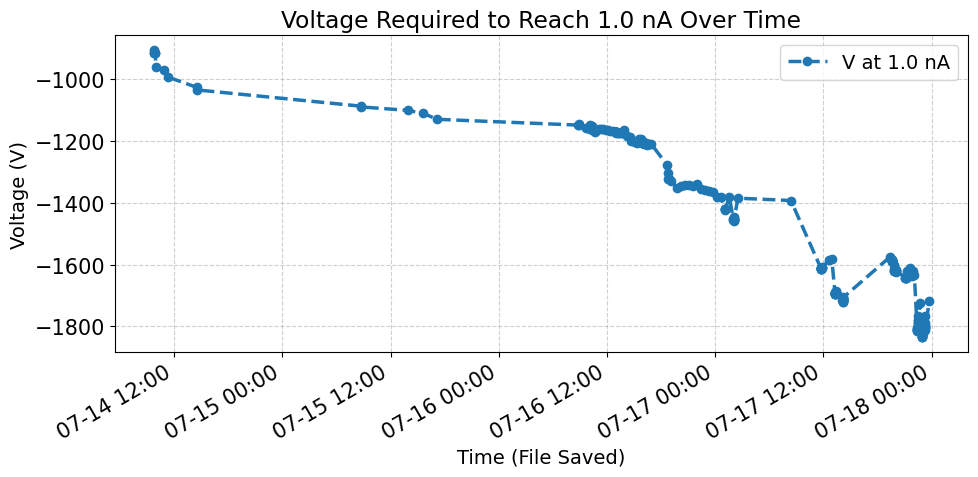

In [36]:
home_dir = '/home/electron/'
plot_voltage_at_target_current([home_dir+'data/experiment_07122026',
                                home_dir+'data/experiment_07132026',
                                home_dir+'data/experiment_07142026',
                                home_dir+'data/experiment_07152026',
                                home_dir+'data/experiment_07162026', 
                                home_dir+'data/experiment_07172026',
                                home_dir+'data/experiment_07182026'], 
                                'TipVoltageSweepDifferential', target_current=1.0)